### K-Means 

In [1]:
# Fake Data
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, Y = make_blobs(
    n_samples=200,
    n_features=2,
    centers=3,
    cluster_std=1,
    shuffle=True,
    random_state=7
)

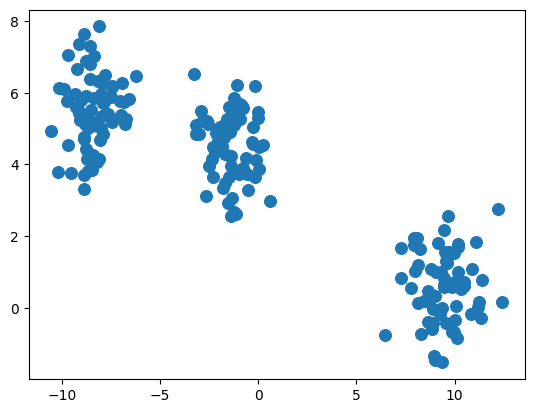

In [2]:
plt.scatter(X[:, 0], X[:,1], marker='o', s=70)
plt.show()

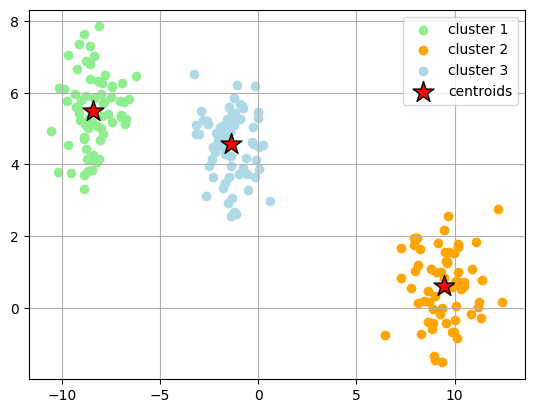

In [6]:
#K-Means Fit
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, max_iter=500)
y_km = km.fit_predict(X)

#plot the 3 clusters
plt.scatter(X[y_km == 0, 0], X[y_km == 0, 1], c='lightgreen', label='cluster 1')
plt.scatter(X[y_km == 1, 0], X[y_km == 1, 1], c='orange', label='cluster 2')
plt.scatter(X[y_km == 2, 0], X[y_km == 2, 1], c='lightblue', label='cluster 3')

#plot the centroids
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:,1], s=250, marker='*', c='red', edgecolor='black', label='centroids')
plt.legend(scatterpoints=1)
plt.grid()


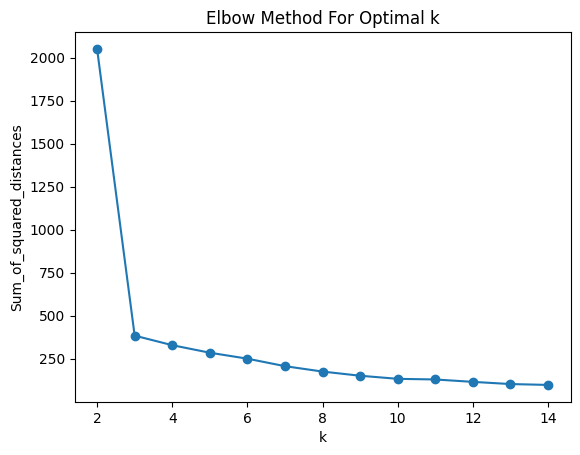

In [9]:
#Elbow Method
Sum_of_squared_distances = []
K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k, init='random', n_init=10, max_iter=500, random_state=0)
    km = km.fit(X)

    Sum_of_squared_distances.append(km.inertia_)

# Plot Results
plt.plot(K, Sum_of_squared_distances, marker='o')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()


In [10]:
#Silhouette Analysis
from sklearn.metrics import silhouette_score
for n_clusters in range(2,10):
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is: {:4f}".format(silhouette_avg))

For n_clusters = 2 The average silhouette_score is: 0.748643
For n_clusters = 3 The average silhouette_score is: 0.785358
For n_clusters = 4 The average silhouette_score is: 0.641820
For n_clusters = 5 The average silhouette_score is: 0.461010
For n_clusters = 6 The average silhouette_score is: 0.477107
For n_clusters = 7 The average silhouette_score is: 0.325233
For n_clusters = 8 The average silhouette_score is: 0.478205
For n_clusters = 9 The average silhouette_score is: 0.361148


### Case Study
#### Clusering Travel Agency Booking Data


In [11]:
#Downloading The Data
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/clustering/travel.csv',
parse_dates = ['date_time','srch_ci','srch_co'])
df.head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,...,0,1,8286,1,0,1,0,63,1258,68
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,...,0,1,1842,3,0,1,2,198,786,37
2,2014-10-13 13:20:00,2,3,66,314,48562,4468.2720,495669,0,1,...,0,1,8746,1,0,1,6,105,29,22
3,2013-11-05 10:40:00,11,3,205,411,52752,171.6021,106611,0,0,...,0,1,6210,3,1,1,2,198,1234,42
4,2014-06-10 13:34:00,2,3,66,174,50644,NaN,596177,0,0,...,1,1,12812,5,0,1,2,50,368,83


In [12]:
df.to_csv('../data/clustering/travel.csv')

In [13]:
# Get some base information on our dataset
print ("Rows:   " , df.shape[0])
print ("Columns: " , df.shape[1])

Rows:    100000
Columns:  24


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date_time                  100000 non-null  datetime64[us]
 1   site_name                  100000 non-null  int64         
 2   posa_continent             100000 non-null  int64         
 3   user_location_country      100000 non-null  int64         
 4   user_location_region       100000 non-null  int64         
 5   user_location_city         100000 non-null  int64         
 6   orig_destination_distance  63915 non-null   float64       
 7   user_id                    100000 non-null  int64         
 8   is_mobile                  100000 non-null  int64         
 9   is_package                 100000 non-null  int64         
 10  channel                    100000 non-null  int64         
 11  srch_ci                    99878 non-null   datetime64[us]
 12  

In [15]:
# Get statistics for our Numerical Columns
df.isnull().sum()

date_time                        0
site_name                        0
posa_continent                   0
user_location_country            0
user_location_region             0
user_location_city               0
orig_destination_distance    36085
user_id                          0
is_mobile                        0
is_package                       0
channel                          0
srch_ci                        122
srch_co                        122
srch_adults_cnt                  0
srch_children_cnt                0
srch_rm_cnt                      0
srch_destination_id              0
srch_destination_type_id         0
is_booking                       0
cnt                              0
hotel_continent                  0
hotel_country                    0
hotel_market                     0
hotel_cluster                    0
dtype: int64

In [16]:
# Create our Corelation Matrix
corr = df.corr()
corr

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
date_time,1.000000,-0.024018,-0.010503,-0.021281,-0.012536,-0.004335,-0.002967,-0.017718,0.023642,-0.001773,...,-0.075139,-0.004368,0.011650,-0.040562,-0.032699,-0.089140,-0.008460,-0.005722,0.003028,-0.000059
site_name,-0.024018,1.000000,-0.637743,0.159283,0.130818,-0.013471,0.027609,0.030404,-0.005418,0.048820,...,-0.031962,0.016585,0.034895,-0.006934,-0.013460,0.022274,0.201760,0.263167,-0.068316,-0.026689
posa_continent,-0.010503,-0.637743,1.000000,0.179726,-0.034647,0.039227,0.049808,-0.015209,0.016331,-0.093459,...,0.034453,-0.033712,-0.015535,0.037172,0.013319,-0.018952,-0.333578,-0.156578,0.049214,0.018297
user_location_country,-0.021281,0.159283,0.179726,1.000000,0.058496,0.122686,0.047689,-0.021091,0.003728,-0.025284,...,0.037101,0.000858,0.013486,0.028888,0.001284,0.003539,-0.063744,0.097624,0.015569,-0.011876
user_location_region,-0.012536,0.130818,-0.034647,0.058496,1.000000,0.132457,0.136560,0.002225,0.016982,0.040482,...,0.014009,0.000254,0.022567,0.001376,0.000253,-0.007570,0.043027,-0.050301,0.040367,0.004984
user_location_city,-0.004335,-0.013471,0.039227,0.122686,0.132457,1.000000,0.014178,-0.007989,-0.003741,0.013032,...,0.002638,-0.000694,0.000786,-0.004399,-0.002655,-0.002175,0.007759,-0.001987,0.008558,0.000102
orig_destination_distance,-0.002967,0.027609,0.049808,0.047689,0.136560,0.014178,1.000000,0.017015,-0.059464,0.041991,...,-0.059722,-0.012484,-0.036314,-0.042859,-0.033480,0.009483,0.416180,0.254321,-0.090112,0.003624
user_id,-0.017718,0.030404,-0.015209,-0.021091,0.002225,-0.007989,0.017015,1.000000,-0.011439,-0.018901,...,0.002983,-0.001625,0.002716,0.007133,0.001561,0.001355,0.002447,0.008707,-0.002463,0.003202
is_mobile,0.023642,-0.005418,0.016331,0.003728,0.016982,-0.003741,-0.059464,-0.011439,1.000000,0.046903,...,0.018211,-0.022565,-0.007140,-0.016039,-0.028623,0.008084,-0.024144,-0.029574,0.007644,0.012145
is_package,-0.001773,0.048820,-0.093459,-0.025284,0.040482,0.013032,0.041991,-0.018901,0.046903,1.000000,...,-0.037673,-0.036653,-0.146647,-0.224422,-0.081307,0.126500,0.108993,-0.044426,-0.014636,0.031399


Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

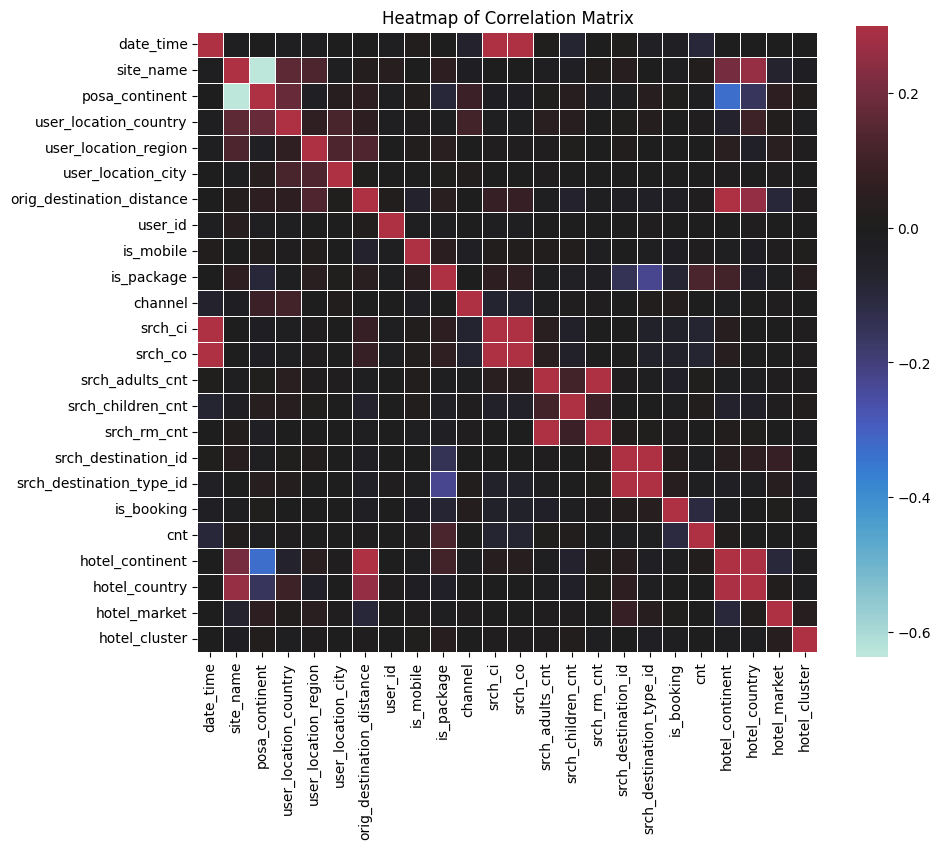

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,10))

sns.heatmap(corr,xticklabels=corr.columns.values,
           yticklabels=corr.columns.values,vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Heatmap of Correlation Matrix')

array([[<Axes: title={'center': 'channel'}>,
        <Axes: title={'center': 'is_booking'}>,
        <Axes: title={'center': 'is_mobile'}>],
       [<Axes: title={'center': 'orig_destination_distance'}>,
        <Axes: title={'center': 'srch_rm_cnt'}>,
        <Axes: title={'center': 'srch_adults_cnt'}>],
       [<Axes: title={'center': 'srch_children_cnt'}>, <Axes: >,
        <Axes: >]], dtype=object)

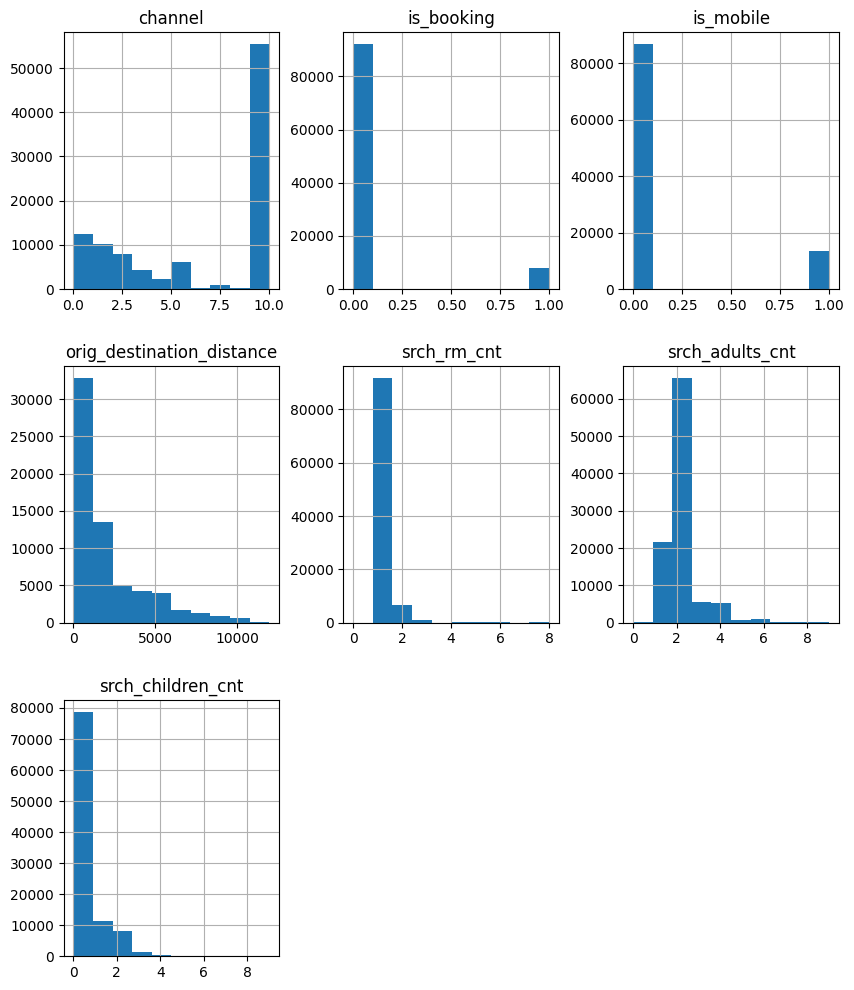

In [19]:
#Distributions
df[['channel', 'is_booking', 'is_mobile', 'orig_destination_distance',
        'srch_rm_cnt', 'srch_adults_cnt', 'srch_children_cnt']].hist(figsize=(10,12))

In [20]:
#is_booking
#To view the bookings made per user
booking_count_per_user=df.groupby('user_id')['is_booking'].agg(num_of_bookings='count').reset_index()
booking_count_per_user.groupby('num_of_bookings')['user_id'].agg('count')

num_of_bookings
1    79189
2     8423
3     1065
4      161
5       24
6        1
Name: user_id, dtype: int64

In [22]:
#Merge with the Original Data
df = df.merge(
    df.groupby('user_id')['is_booking']
    .agg(['count'])
    .reset_index()
    )
df.head()


,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,count
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,...,1,8286,1,0,1,0,63,1258,68,2
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,...,1,1842,3,0,1,2,198,786,37,1
2,2014-10-13 13:20:00,2,3,66,314,48562,4468.2720,495669,0,1,...,1,8746,1,0,1,6,105,29,22,1
3,2013-11-05 10:40:00,11,3,205,411,52752,171.6021,106611,0,0,...,1,6210,3,1,1,2,198,1234,42,2
4,2014-06-10 13:34:00,2,3,66,174,50644,NaN,596177,0,0,...,1,12812,5,0,1,2,50,368,83,1
